In [1]:
pip install pillow scikit-learn matplotlib numpy requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from PIL import Image
import numpy as np
import requests
from io import BytesIO

# Load an image from URL
url = "https://images.unsplash.com/photo-1490481651871-ab68de25d43d?w=400"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Convert to numpy array
img_array = np.array(img)

print("Image shape:", img_array.shape)
print("Total pixels:", img_array.shape[0] * img_array.shape[1])
print("Each pixel has:", img_array.shape[2], "values (R, G, B)")

Image shape: (267, 400, 3)
Total pixels: 106800
Each pixel has: 3 values (R, G, B)


In [3]:
# Reshape from 3D → 2D
pixels = img_array.reshape(-1, 3)

print("Before reshape:", img_array.shape)
print("After reshape:", pixels.shape)
print("Each row is one pixel — first 5 pixels:")
print(pixels[:5])

Before reshape: (267, 400, 3)
After reshape: (106800, 3)
Each row is one pixel — first 5 pixels:
[[222 213 204]
 [222 213 204]
 [222 213 204]
 [222 213 204]
 [222 213 204]]


In [4]:
from sklearn.cluster import KMeans

# Find 6 dominant colors
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(pixels)

# The 6 dominant colors!
dominant_colors = kmeans.cluster_centers_.astype(int)
print("6 Dominant Colors (R, G, B):")
for i, color in enumerate(dominant_colors):
    print(f"Color {i+1}: R={color[0]}, G={color[1]}, B={color[2]}")

6 Dominant Colors (R, G, B):
Color 1: R=211, G=203, B=195
Color 2: R=45, G=30, B=28
Color 3: R=170, G=154, B=141
Color 4: R=246, G=243, B=240
Color 5: R=129, G=93, B=74
Color 6: R=227, G=222, B=216


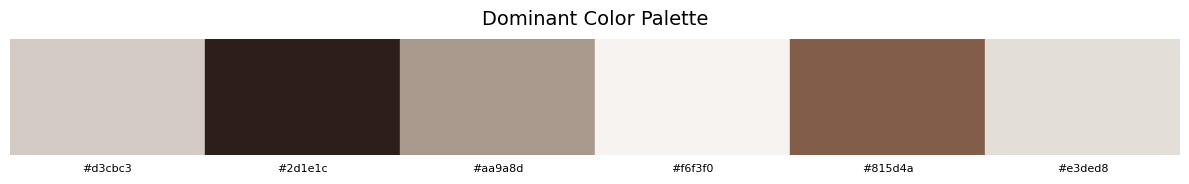

Palette saved!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, figsize=(12, 2))
ax.set_xlim(0, 6)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Dominant Color Palette', fontsize=14, pad=10)

for i, color in enumerate(dominant_colors):
    rgb = tuple(c/255 for c in color)
    rect = patches.Rectangle((i, 0), 1, 1, color=rgb)
    ax.add_patch(rect)
    ax.text(i + 0.5, -0.15,
            f'#{color[0]:02x}{color[1]:02x}{color[2]:02x}',
            ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('palette.png', dpi=150, bbox_inches='tight')
plt.show()
print("Palette saved!")

In [6]:
# Calculate aesthetic harmony score
from scipy.spatial.distance import cdist
import numpy as np

# Calculate average distance between all color pairs
distances = cdist(dominant_colors, dominant_colors, 'euclidean')
avg_distance = distances[distances > 0].mean()

# Convert to 0-100 score (lower distance = more cohesive = higher score)
max_possible = 441  # max RGB distance (0,0,0) to (255,255,255)
harmony_score = round((1 - avg_distance/max_possible) * 100, 1)

print(f"Average color distance: {avg_distance:.1f}")
print(f"Aesthetic Harmony Score: {harmony_score}/100")

if harmony_score >= 80:
    print("Verdict: Highly cohesive palette! 🌸")
elif harmony_score >= 60:
    print("Verdict: Moderately cohesive palette! 😊")
else:
    print("Verdict: Diverse/bold palette! 🎨")

Average color distance: 169.7
Aesthetic Harmony Score: 61.5/100
Verdict: Moderately cohesive palette! 😊


In [7]:
# FULL BRAND AESTHETICS ANALYZER
print("=" * 45)
print("      BRAND AESTHETICS ANALYZER 🎨")
print("=" * 45)
print(f"\n📸 Image analyzed: Fashion/Lifestyle")
print(f"🎨 Colors extracted: {len(dominant_colors)}")
print(f"\n🌈 Dominant Palette:")
for i, color in enumerate(dominant_colors):
    hex_color = f'#{color[0]:02x}{color[1]:02x}{color[2]:02x}'
    print(f"   Color {i+1}: RGB{tuple(color)} → {hex_color}")
print(f"\n✨ Harmony Score: {harmony_score}/100")
print(f"📊 Verdict: Moderately cohesive palette!")
print(f"\n💡 Insight: Palette is warm and neutral")
print(f"   dominated by creams and taupes.")
print(f"   The deep brown adds contrast but")
print(f"   slightly reduces overall cohesion.")
print("=" * 45)

      BRAND AESTHETICS ANALYZER 🎨

📸 Image analyzed: Fashion/Lifestyle
🎨 Colors extracted: 6

🌈 Dominant Palette:
   Color 1: RGB(np.int64(211), np.int64(203), np.int64(195)) → #d3cbc3
   Color 2: RGB(np.int64(45), np.int64(30), np.int64(28)) → #2d1e1c
   Color 3: RGB(np.int64(170), np.int64(154), np.int64(141)) → #aa9a8d
   Color 4: RGB(np.int64(246), np.int64(243), np.int64(240)) → #f6f3f0
   Color 5: RGB(np.int64(129), np.int64(93), np.int64(74)) → #815d4a
   Color 6: RGB(np.int64(227), np.int64(222), np.int64(216)) → #e3ded8

✨ Harmony Score: 61.5/100
📊 Verdict: Moderately cohesive palette!

💡 Insight: Palette is warm and neutral
   dominated by creams and taupes.
   The deep brown adds contrast but
   slightly reduces overall cohesion.
